# Evaluation

<a target="_blank" href="https://colab.research.google.com/github/pleyad/Summer-School-2026/blob/main/notebooks/XX_evaluation.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Housekeeping

In [ ]:
%pip install scikit-learn seaborn

❗ Please restart the kernel/runtime after installing the packages to ensure that all changes take effect.

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    cohen_kappa_score,
)

In [2]:
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
DATA_DIR = Path('/content/drive/MyDrive/ZBSummerSchool26/data') if IN_COLAB else Path('../data')

# TODO: define module number
ZB_MODULE = '06'

## Setup (Interaction required)

In [3]:
### ⬇️⬇️⬇️ 💽 Adjust here if you want to load the data from your google drive
CORPUS_NAME = "armenpflege"
#LOAD_OWN_DATA = True
LOAD_OWN_DATA = False 
YOUR_NAME = "niclas"
SEPARATOR = ";" # Separator for the CSV file, e.g., ";" for semicolon, "," for comma
### ⬆️⬆️⬆️

In [4]:
if IN_COLAB and LOAD_OWN_DATA: # and confirm("Do you want to mount your Google Drive?"):
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DATA_DIR, exist_ok=True)

## Load the data

Dieses Notebook erwartet zwei Dateien mit je den Spalten `id` und `label`:

| Datei | Inhalt |
|---|---|
| `{CORPUS_NAME}.gold.csv` | Menschliche Annotationen aus LabelStudio (Gold Standard) |
| `{CORPUS_NAME}.predictions.csv` | Automatische Labels des LLM aus `XX_Labeling` |

Falls eure Dateien andere Spaltennamen verwenden, bitte oben die Konfiguration anpassen oder die Spalten nach dem Laden umbenennen.

#### <img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=16> Load your own data from Google Drive

In [5]:
# TODO: define paths
if LOAD_OWN_DATA:
    GOLD_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.pp.label.{YOUR_NAME}.csv"
    PRED_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.pp.label.llm.csv"

    gold_df = pd.read_csv(GOLD_PATH, sep=SEPARATOR)
    pred_df = pd.read_csv(PRED_PATH, sep=SEPARATOR)

    print(f'{"Gold standard loaded:":<21} {len(gold_df)} entries')
    print(f'{"Predictions loaded:":<21} {len(pred_df)} entries')
    
    if len(gold_df) != len(pred_df):
        print(f'\n⚠️  Warning: Gold standard and predictions have different lengths!')
        print(f'{"":>4}{"Difference:":<12} {abs(len(gold_df) - len(pred_df))} entries')
    
    display(gold_df.head(3))
    display(pred_df.head(3))

#### <img src="https://cdn.simpleicons.org/github" alt="🏫" width=16> Load Data from Github

In [6]:
if not LOAD_OWN_DATA:
    # TODO: Replace with actual GitHub URLs once example files are published
    GOLD_URL = f"https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/{CORPUS_NAME}.filtered.pp.label.{YOUR_NAME}.csv"
    PRED_URL = f"https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/{CORPUS_NAME}.filtered.pp.label.llm.csv"

    print('Loading gold standard ...', end='\r')
    gold_df = pd.read_csv(GOLD_URL, index_col="id", sep=SEPARATOR)
    
    print('Loading predictions   ...', end='\r')
    pred_df = pd.read_csv(PRED_URL, index_col="id")

    print(f'{"Gold standard loaded:":<21} {len(gold_df)} entries')
    print(f'{"Predictions loaded:":<21} {len(pred_df)} entries')
    
    if len(gold_df) != len(pred_df):
        print(f'\n⚠️  Warning: Gold standard and predictions have different lengths!')
        print(f'{"":>4}{"Difference:":<12} {abs(len(gold_df) - len(pred_df))} entries')
    
    print("Gold Data")
    display(gold_df.head(3))
    print("Predictions Data")
    display(pred_df.head(3))

Gold standard loaded: 2602 entries
Predictions loaded:   2602 entries
Gold Data


,url,year,media_title,pseudo_paragraph,label
id,,,,,
NZZ-1914-07-13-b-i0001,https://impresso-project.ch/app/issue/NZZ-1914...,1914,Neue Zürcher Zeitung,In d: r Abstimmung lehnt der Rat die Subventio...,Unspezifischer Bericht
NZZ-1881-07-13-b-i0005,https://impresso-project.ch/app/issue/NZZ-1881...,1881,Neue Zürcher Zeitung,Vor zehn Iahren be irgend eine andere protegir...,Meinungsartikel
DTT-1973-12-25-a-i0146,https://impresso-project.ch/app/issue/DTT-1973...,1973,Die Tat,Der Verein will im kommenden Wahlkampf einen e...,Unspezifischer Bericht


Predictions Data


,predicted_label,reasoning
id,,
handelsztg-1882-08-17-a-i0002,Unspezifischer Bericht,Sachlicher Tätigkeitsbericht über Entwicklung ...
luxwort-1933-10-21-a-i0006,Meinungsartikel,Der Abschnitt ist ein argumentativer kirchlich...
DTT-1945-09-06-a-i0013,Unspezifischer Bericht,Sachliche Meldung über Subventionen und Beiträ...


## Vorbereitung: Merge der DataFrames

Wir verbinden Gold Standard und Predictions über die `id`-Spalte. Da jede Textpassage genau ein Label hat, verwenden wir einen **Inner Join**.

Falls die Anzahl Dokumente vor und nach dem Merge nicht übereinstimmt, fehlt für einige IDs entweder eine Annotation oder eine Prediction.

In [7]:
eval_df = (
    gold_df[gold_df['label'].notna()].merge(pred_df, on='id', how='inner')
)

print(f'{"Gold standard entries:":<23} {len(gold_df[gold_df["label"].notna()])}')
print(f'{"Predictions entries:":<23} {len(pred_df)}')
print(f'{"Entries after merge:":<23} {len(eval_df)}')
display(eval_df.head(5))

Gold standard entries:  80
Predictions entries:    2602
Entries after merge:    80


,url,year,media_title,pseudo_paragraph,label,predicted_label,reasoning
id,,,,,,,
NZZ-1914-07-13-b-i0001,https://impresso-project.ch/app/issue/NZZ-1914...,1914,Neue Zürcher Zeitung,In d: r Abstimmung lehnt der Rat die Subventio...,Unspezifischer Bericht,Unspezifischer Bericht,"Es geht um Wahl, Betrieb und Kredit der Armenp..."
NZZ-1881-07-13-b-i0005,https://impresso-project.ch/app/issue/NZZ-1881...,1881,Neue Zürcher Zeitung,Vor zehn Iahren be irgend eine andere protegir...,Meinungsartikel,Meinungsartikel,Deutlich wertend und polemisch zur staatlichen...
DTT-1973-12-25-a-i0146,https://impresso-project.ch/app/issue/DTT-1973...,1973,Die Tat,Der Verein will im kommenden Wahlkampf einen e...,Unspezifischer Bericht,Unspezifischer Bericht,Es geht um die organisatorische Neuordnung und...
NZZ-1883-10-14-a-i0005,https://impresso-project.ch/app/issue/NZZ-1883...,1883,Neue Zürcher Zeitung,lichen Zweckc der Gemeinde. Dabei käme ein The...,Meinungsartikel,Unspezifischer Bericht,Der Text diskutiert allgemein die Armenpflege ...
NZZ-1931-08-19-a-i0001,https://impresso-project.ch/app/issue/NZZ-1931...,1931,Neue Zürcher Zeitung,Eine davon betrieb Jahrzehnte hiuduich das Hot...,Unspezifischer Bericht,Unspezifischer Bericht,Berichtet sachlich über eine kantonale Kommiss...


## Diagnose: Unbekannte Prediction-Labels

LLMs können Labels "halluzinieren" — Kategorien erfinden, die im menschlichen Annotation-Schema nicht vorkommen. Solche Fälle sind ein qualitativer Hinweis auf Modell- oder Prompt-Probleme.

Unbekannte Labels zählen als **False Negative der jeweiligen Gold-Klasse**: Das Modell hat die korrekte Klasse verfehlt. Sie werden auf den Platzhalter `'[unbekannt]'` gemappt, damit sie in der Metrik-Berechnung korrekt berücksichtigt werden.

> **Technische Hintergrundinformation:** `sklearn` würde Instanzen mit unbekannten Prediction-Labels
> stillschweigend verwerfen, wenn man nur die Gold-Klassen als `labels` übergibt. Der False Negative
> für die Gold-Klasse würde damit nicht gezählt — das wäre falsch. Durch den Sentinel als zusätzliche
> Klasse bleiben alle Instanzen im Datensatz erhalten.

In [ ]:
ERROR_LABEL = "error"  # Placeholder for prediction labels not in the gold standard

In [47]:
gold_label_list = sorted(eval_df['gold'].unique())
unknown = set(eval_df['pred'].unique()) - set(gold_label_list)

if unknown:
    n_affected = eval_df['pred'].isin(unknown).sum()
    print(f'⚠  Labels in Predictions, die nicht im Gold Standard vorkommen: {unknown}')
    print(f'   Anzahl betroffener Dokumente: {n_affected}')
    print(f"   Diese werden auf '{UNKNOWN_SENTINEL}' gemappt")
    print(f'   und zählen als False Negative der jeweiligen Gold-Klasse.')
else:
    print('✓  Alle Prediction-Labels sind im Gold Standard bekannt.')

# Mapping: unbekannte Labels → Sentinel
eval_df['pred_mapped'] = eval_df['pred'].apply(
    lambda x: x if x in gold_label_list else UNKNOWN_SENTINEL
)

# Labels für sklearn: Gold-Klassen + Sentinel (nur wenn er tatsächlich vorkommt)
has_unknown = UNKNOWN_SENTINEL in eval_df['pred_mapped'].values
sklearn_labels = gold_label_list + ([UNKNOWN_SENTINEL] if has_unknown else [])

✓  Alle Prediction-Labels sind im Gold Standard bekannt.


## Label-Verteilung im Gold Standard

Bevor wir Metriken berechnen, lohnt es sich, die Verteilung der Labels zu betrachten. Stark unausgeglichene Klassen beeinflussen, wie aussagekräftig verschiedene Metriken sind — dazu mehr im Abschnitt *Recall bei seltenen Labels*.

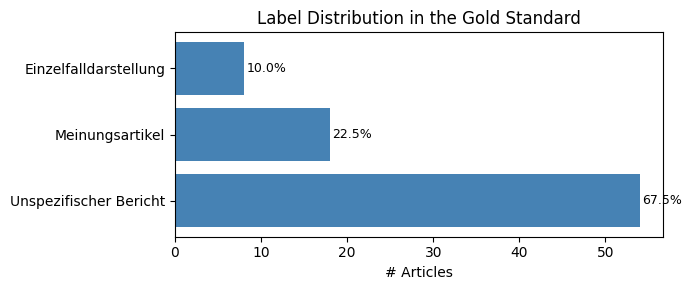

                 label  count  percentage
Unspezifischer Bericht     54       0.675
       Meinungsartikel     18       0.225
 Einzelfalldarstellung      8       0.100


In [8]:
label_freq = (
    eval_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)
label_freq["percentage"] = label_freq["count"] / label_freq["count"].sum()

fig, ax = plt.subplots(figsize=(7, max(3, len(label_freq) * 0.6)))
bars = ax.barh(label_freq["label"], label_freq["count"], color="steelblue")
for bar, percentage in zip(bars, label_freq["percentage"]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.1%}",
        va="center",
        fontsize=9,
    )
ax.set_xlabel("# Articles")
ax.set_title("Label Distribution in the Gold Standard")
plt.tight_layout()
plt.show()

print(label_freq.to_string(index=False))

## Metriken

Wir berechnen vier Metriken pro Klasse sowie aggregierte Werte:

| Metrik | Frage |
|---|---|
| **Precision** | Von allen Instanzen, die das Modell als Klasse X klassifiziert hat: wie viele waren tatsächlich X? |
| **Recall** | Von allen Instanzen, die wirklich Klasse X sind: wie viele hat das Modell gefunden? |
| **F1-Score** | Harmonisches Mittel aus Precision und Recall |
| **Accuracy** | Anteil aller korrekt klassifizierten Instanzen |

Die Aggregation **Macro avg** behandelt alle Klassen gleichwertig — auch seltene Klassen zählen gleich viel. **Weighted avg** gewichtet nach Häufigkeit.

**Cohen's κ** misst die Übereinstimmung zwischen Modell und Mensch abzüglich zufälliger Übereinstimmung — robuster als reine Accuracy:
- κ < 0.4: schwache Übereinstimmung
- κ 0.4–0.6: moderate Übereinstimmung  
- κ > 0.8: starke Übereinstimmung

In [9]:
# Use predicted labels for the report to ensure that the error class is included
label_list = sorted(eval_df["predicted_label"].unique())
true_labels = eval_df["label"]
predicted_labels = eval_df["predicted_label"]

# Pass the label list to sklearn to ensure that all classes (including the error class) are included in the report
report = classification_report(
    true_labels, predicted_labels,
    labels=label_list,
    zero_division=0,
    output_dict=True,
)

print(report)

# Sentinel-Zeile ausblenden — nur Gold-Klassen + Aggregat anzeigen
# Convert true_labels to list
gold_label_list = sorted(eval_df["label"].unique())
display_rows = gold_label_list + ["macro avg", "weighted avg"]
report_df = pd.DataFrame(report).T.loc[display_rows]
print(report_df.round(3).to_string())

accuracy = report['accuracy']
kappa = cohen_kappa_score(true_labels, predicted_labels)
print(f'\nAccuracy : {accuracy:.3f}')
print(f"Cohen's κ: {kappa:.3f}")

{'Einzelfalldarstellung': {'precision': 1.0, 'recall': 0.75, 'f1-score': 0.8571428571428571, 'support': 8.0}, 'Meinungsartikel': {'precision': 0.6086956521739131, 'recall': 0.7777777777777778, 'f1-score': 0.6829268292682927, 'support': 18.0}, 'Unspezifischer Bericht': {'precision': 0.88, 'recall': 0.8148148148148148, 'f1-score': 0.8461538461538461, 'support': 54.0}, 'error': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}, 'accuracy': 0.8, 'macro avg': {'precision': 0.6221739130434782, 'recall': 0.5856481481481481, 'f1-score': 0.596555883141249, 'support': 80.0}, 'weighted avg': {'precision': 0.8309565217391306, 'recall': 0.8, 'f1-score': 0.8105266684534979, 'support': 80.0}}
                        precision  recall  f1-score  support
Einzelfalldarstellung       1.000   0.750     0.857      8.0
Meinungsartikel             0.609   0.778     0.683     18.0
Unspezifischer Bericht      0.880   0.815     0.846     54.0
macro avg                   0.622   0.586     0.597 

## Konfusionsmatrix

Die Konfusionsmatrix zeigt, welche Klassen miteinander verwechselt werden:

- **Zeilen** = Gold Standard (was eine Instanz wirklich ist)
- **Spalten** = Prediction des Modells
- **Diagonale** = korrekte Klassifikationen
- **Ausserhalb der Diagonale** = Fehler — welche Klasse wurde mit welcher verwechselt?

Die **normierte Variante** (rechts) zeigt den Recall je Klasse direkt auf der Diagonalen: Welcher Anteil einer Gold-Klasse wurde korrekt erkannt? Alles ausserhalb — inklusive einer `[unbekannt]`-Spalte, falls das Modell halluziniert hat — sind verfehlte Instanzen (False Negatives).

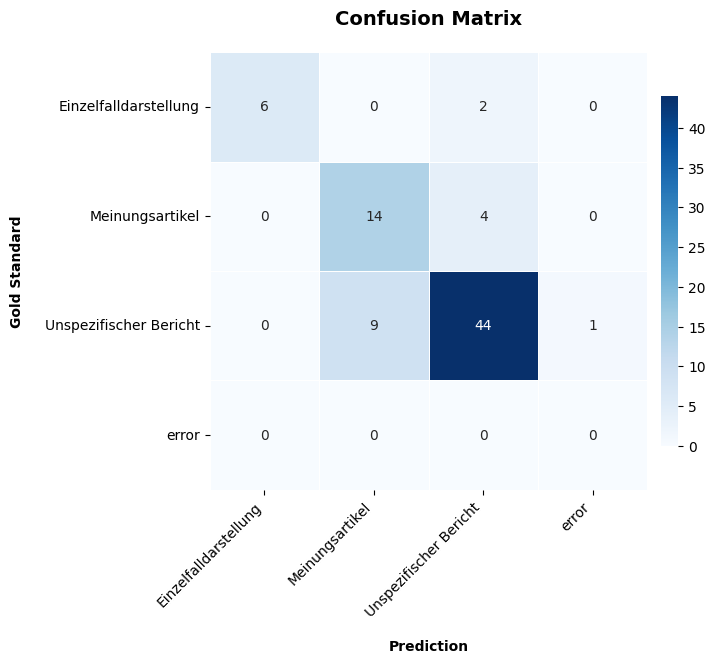

In [10]:
# pd.crosstab zeigt automatisch alle Prediction-Spalten, inkl. [unbekannt] falls vorhanden
confusion_matrix_df = pd.crosstab(
    eval_df["label"],
    eval_df["predicted_label"],
    rownames=["Gold Standard"],
    colnames=["Predicted"],
)

# Alle Gold-Klassen als Zeilen sicherstellen (auch wenn nie vorhergesagt)
confusion_matrix_df = confusion_matrix_df.reindex(index=label_list, fill_value=0)

plt.figure(figsize=(9, 7))

# Confusion matrix with absolute counts
sns.heatmap(confusion_matrix_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8, "pad": 0.02})

plt.title("Confusion Matrix", pad=20, fontsize=14, fontweight='bold')
plt.xlabel("Prediction", fontweight='bold', labelpad=15)
plt.ylabel("Gold Standard", fontweight='bold', labelpad=15)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout(pad=2.0)
plt.show()

In [14]:
cm_norm = confusion_matrix_df.div(confusion_matrix_df.sum(axis=1), axis=0).fillna(0).round(2)
print(cm_norm.head(10))

Predicted               Einzelfalldarstellung  Meinungsartikel  \
Gold Standard                                                    
Einzelfalldarstellung                    0.75             0.00   
Meinungsartikel                          0.00             0.78   
Unspezifischer Bericht                   0.00             0.17   
error                                    0.00             0.00   

Predicted               Unspezifischer Bericht  error  
Gold Standard                                          
Einzelfalldarstellung                     0.25   0.00  
Meinungsartikel                           0.22   0.00  
Unspezifischer Bericht                    0.81   0.02  
error                                     0.00   0.00  


In [ ]:
# Normiert nach Zeilensumme → Diagonale = Recall je Klasse
cm_norm = confusion_matrix_df.div(confusion_matrix_df.sum(axis=1), axis=0).fillna(0).round(2)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8, "pad": 0.02})
plt.title("Normed Confusion Matrix (Recall Perspective)", pad=20, fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontweight='bold', labelpad=15)
plt.ylabel("Gold Standard", fontweight='bold', labelpad=15)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout(pad=2.0)
plt.show()

NotImplementedError: fill_value 0.0 not supported.

## Recall bei seltenen Labels

Ein häufiges Missverständnis: ein Modell mit hoher **Accuracy** ist automatisch gut. Das stimmt nicht, sobald die Labels ungleich verteilt sind.

**Gedankenexperiment:** Stell dir vor, 95 % aller Dokumente haben das Label `neutral` und nur 5 % das Label `positiv`. Ein Modell, das *immer* `neutral` vorhersagt, erreicht **95 % Accuracy** — und findet trotzdem kein einziges positives Dokument.

> **Accuracy belohnt das häufige Label. Recall schützt das seltene.**

**Recall** fragt: *Von allen Dokumenten, die wirklich das Label X haben — wie viele hat das Modell gefunden?* Bei seltenen Klassen ist das besonders relevant: genau diese Dokumente sind oft die inhaltlich interessantesten Fälle — und werden am leichtesten übersehen.

Der folgende Code demonstriert diesen Effekt mit den echten Daten aus dem Korpus:

In [51]:
# Seltenste Klasse im Gold Standard
rarest = freq.iloc[-1]
rarest_label = rarest['label']
rarest_count = int(rarest['count'])
rarest_share = rarest['share']

r = report_df.loc[rarest_label]

print(f"Seltenste Klasse: '{rarest_label}'")
print(f'  Anzahl Dokumente: {rarest_count} ({rarest_share:.1%} des Korpus)')
print()
print(f"  Precision : {r['precision']:.3f}")
print(f"  Recall    : {r['recall']:.3f}")
print(f"  F1-Score  : {r['f1-score']:.3f}")
print()
print(f'Gesamt-Accuracy: {acc:.3f}')
print()
print('→ Hohe Accuracy kann trotz niedrigem Recall beim seltenen Label auftreten.')
print('→ Macro F1 und Macro Recall gewichten alle Klassen gleichwertig')
print('  und sind daher robustere Metriken bei unausgeglichenen Datensätzen.')

Seltenste Klasse: 'MNO'
  Anzahl Dokumente: 3 (30.0% des Korpus)

  Precision : 0.667
  Recall    : 0.667
  F1-Score  : 0.667

Gesamt-Accuracy: 0.700

→ Hohe Accuracy kann trotz niedrigem Recall beim seltenen Label auftreten.
→ Macro F1 und Macro Recall gewichten alle Klassen gleichwertig
  und sind daher robustere Metriken bei unausgeglichenen Datensätzen.


## Zusammenfassung

In [ ]:
summary = pd.DataFrame({
    'Metrik': ['Accuracy', "Cohen's κ", 'Macro Precision', 'Macro Recall', 'Macro F1'],
    'Wert': [
        acc,
        kappa,
        report['macro avg']['precision'],
        report['macro avg']['recall'],
        report['macro avg']['f1-score'],
    ]
})

print(summary.round(3).to_string(index=False))

# Optional: Ergebnisse als CSV speichern
# summary.to_csv(DATA_DIR / f'{CORPUS_NAME}.evaluation_summary.csv', index=False)

         Metrik  Wert
       Accuracy 0.700
      Cohen's κ 0.545
Macro Precision 0.694
   Macro Recall 0.694
       Macro F1 0.694
